#### Chain Of Thoughts With RAG
What is Chain-of-Thought (CoT) in RAG?

CoT reasoning breaks down a complex question into intermediate steps, and allows retrieval + reflection at each step before answering.

User Query
   ↓
- Step 1: Decompose question → sub-steps (Reason)
- Step 2: Retrieve docs per step (Act)
- Step 3: Combine context (Observe)
- Step 4: Final answer generation (Reflect)

In [2]:

import os
from typing import List
from pydantic import BaseModel
from langchain_core.documents  import Document
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import TextLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph, END

In [3]:
# -------------------------------
# 1. Prepare Vectorstore
# -------------------------------
docs = TextLoader("research_notes.txt",encoding="utf-8").load()
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(docs)
embedding = HuggingFaceEmbeddings()
vectorstore = FAISS.from_documents(chunks, embedding)
retriever = vectorstore.as_retriever()

In [4]:
import os
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
llm = init_chat_model(
    "llama-3.3-70b-versatile",
    model_provider="groq"
)

In [7]:
# -------------------------------
# 2. LangGraph State Definition
# -------------------------------
class RAGCoTState(BaseModel):
    question: str
    sub_steps: List[str] = []
    retrieved_docs: List[Document] = []
    answer: str = ""

In [17]:
# -------------------------------
# 3. Nodes
# -------------------------------

# a. Plan sub-questions
def plan_steps(state:RAGCoTState):
    prompt = f"Break the question into 2-3 reasoning steps: \n\n {state.question}"
    result = llm.invoke(prompt).content
    subqs=[line.strip("-") for line in result.split("\n") if line.strip()]
    return state.model_copy(update={"sub_steps":subqs})


In [18]:
# b. Retrieve for each step
def retriever_per_step(state:RAGCoTState)->RAGCoTState:
    all_docs=[]
    for sub in state.sub_steps:
        docs = retriever.invoke(sub)
        all_docs.extend(docs)
    return state.model_copy(update={"retrieved_docs":all_docs})

In [22]:
# c. Generate Final Answer
def generate_answer(state: RAGCoTState) -> RAGCoTState:
    
    context = "\n\n".join([doc.page_content for doc in state.retrieved_docs])
    prompt = f"""
You are answering a complex question using reasoning and retrieved documents.

Question: {state.question}

Relevant Information:
{context}

Now synthesize a well-reasoned final answer.
"""
    result = llm.invoke(prompt).content.strip()
    return state.model_copy(update={"answer": result})

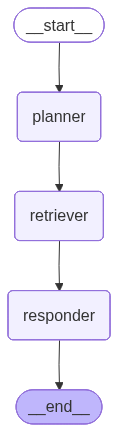

In [23]:
# -------------------------------
# 4. LangGraph Graph
# -------------------------------
builder = StateGraph(RAGCoTState)
builder.add_node("planner", plan_steps)
builder.add_node("retriever", retriever_per_step)
builder.add_node("responder", generate_answer)

builder.set_entry_point("planner")
builder.add_edge("planner", "retriever")
builder.add_edge("retriever", "responder")
builder.add_edge("responder", END)

graph = builder.compile()
graph

In [28]:
# -------------------------------
# 5. Run CoT RAG Agent
# -------------------------------
if __name__ == "__main__":
    query = "what are the additional eperiments in Transformer eveluation?"
    state = RAGCoTState(question=query)
    final = graph.invoke(state)

    print("\n🪜 Reasoning Steps:", final["sub_steps"])
    print("\n✅ Final Answer:\n", final["answer"])


🪜 Reasoning Steps: ["To address the question of additional experiments in Transformer evaluation, let's break it down into reasoning steps:", "1. **Understanding the Basics of Transformer Evaluation**: The first step is to understand what the Transformer model is and how it's typically evaluated. The Transformer model, introduced by Vaswani et al. in 2017, is a deep learning model that relies entirely on self-attention mechanisms to process sequences of data, such as text. Common evaluation metrics for Transformers include perplexity for language modeling tasks, accuracy or F1-score for classification tasks, and BLEU score for translation tasks.", '2. **Identifying Standard Experiments**: The next step involves recognizing the standard experiments or evaluations that are commonly conducted on Transformer models. These can include training the model on a specific dataset (like WikiText for language modeling or IMDB for sentiment analysis), comparing it with other state-of-the-art model